# 실습 3-1 : Random Forest

#### **<실습 내용>**

1. 실습 데이터 탐색 및 전처리
- 분류 데이터 (MachineFailure)
- 회귀 데이터 (Concrete)

2. Random Forest Classifier
- 모델 학습 및 성능 평가
- 변수 중요도 시각화

3. Random Forest Regressor
- 모델 학습 및 성능 평가
- 변수 중요도 시각화

4. 하이퍼 파라미터 최적화
- GridSearchCV를 활용한 최적 파라미터 탐색

## 분석 준비

### 주요 라이브러리 호출

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

---

## 1) 분류 문제

In [ ]:
MF_Data = pd.read_csv(os.path.join(os.getcwd(), "dataset", "day3-1_cls_data.csv"))
MF_Data.head()

In [ ]:
print("데이터 크기 :", MF_Data.shape)
print("출력변수 분포:")
print(MF_Data["Failure"].value_counts())

In [ ]:
# 입출력 변수 분할
Y_cls = MF_Data["Failure"]
X_cls = MF_Data.drop(["Failure"], axis=1)

# 범주형 변수 처리
X_cls["Measure2"] = X_cls["Measure2"].astype("category")
X_cls["Measure3"] = X_cls["Measure3"].astype("category")
X_cls = pd.get_dummies(X_cls)
cls_columns = X_cls.columns

# 출력변수 인코딩
Y_cls = Y_cls.replace({"No": 0, "Yes": 1})

# 데이터 분할
X_train_cls, X_test_cls, Y_train_cls, Y_test_cls = train_test_split(
    X_cls, Y_cls, test_size=0.3, random_state=0, stratify=Y_cls)

print("학습 데이터 :", X_train_cls.shape)
print("테스트 데이터 :", X_test_cls.shape)

In [ ]:
# 분류 성능 평가 함수
def get_classscore(real, pred):
    print("Accuracy  : %.3f" % accuracy_score(real, pred))
    print("Precision : %.3f" % precision_score(real, pred))
    print("Recall    : %.3f" % recall_score(real, pred))
    print("F1-score  : %.3f" % f1_score(real, pred))
    print()
    print("혼동행렬")
    print(confusion_matrix(real, pred))

---

### 1-1) Random Forest Classifier 모델 학습 및 성능 평가

> **Random Forest**는 Bagging의 일종으로, 붓스트랩 샘플링 + 무작위 변수 선택을 통해 다수의 의사결정나무를 생성하고 결합하는 앙상블 모델임
> - **붓스트랩 샘플링**: 학습 데이터에서 복원 추출로 여러 표본을 만들어 베이스 모델의 다양성을 확보함
> - **무작위 변수 선택**: 각 노드마다 입력변수의 일부만 랜덤 선택하여 트리 간 상관성을 줄임
> - 분류: 다수결 투표, 회귀: 평균으로 최종 예측을 수행함

In [ ]:
RF_cls = RandomForestClassifier()
RF_cls.fit(X_train_cls, Y_train_cls)
RF_cls_pred = RF_cls.predict(X_test_cls)
get_classscore(Y_test_cls, RF_cls_pred)

### 1-2) 변수 중요도 시각화

> Random Forest는 **Mean Decrease in Impurity** 방식으로 변수 중요도를 산출함

> 각 트리에서 특정 변수가 노드 분할에 사용될 때의 불순도 감소량을 평균내어 중요도를 계산함

In [ ]:
# 변수 중요도 추출 및 시각화
var_imp = pd.DataFrame({"Variable": cls_columns, "Importance": RF_cls.feature_importances_})
imp_top10 = var_imp.sort_values(by="Importance", ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Variable", data=imp_top10)
plt.title("Feature Importance Top 10 (Random Forest)")
plt.tight_layout()
plt.show()

### 1-3) 모델 성능 개선

> Random Forest의 주요 하이퍼 파라미터:
>
> | 파라미터 | 의미 |
> |:---:|:---:|
> | n_estimators | 베이스 모델(의사결정나무)의 수 |
> | max_depth | 개별 트리의 최대 깊이 |
> | max_features | 각 노드에서 랜덤 선택하는 변수 수 (분류: sqrt, 회귀: n/3) |
> | min_samples_leaf | 끝 노드의 최소 샘플 수 |
> | min_samples_split | 노드 분할을 위한 최소 샘플 수 |

In [ ]:
params = {
    "max_depth": [3, 5, 7],
    "min_samples_leaf": [2, 4, 8],
    "n_estimators": [100, 300],
    "max_features": ["sqrt", 3]
}

grid_cls = GridSearchCV(
    RandomForestClassifier(random_state=0),
    param_grid=params, cv=5, scoring="f1", n_jobs=-1
)
grid_cls.fit(X_train_cls, Y_train_cls)

print("최적 파라미터:", grid_cls.best_params_)
print("최적 F1-score: %.4f" % grid_cls.best_score_)

In [ ]:
# 최적 모델로 테스트 성능 평가
best_pred_cls = grid_cls.predict(X_test_cls)
get_classscore(Y_test_cls, best_pred_cls)

---

## 2) 회귀 문제

In [ ]:
Concrete = pd.read_csv(os.path.join(os.getcwd(), "dataset", "day3-1_reg_data.csv"))

Y_reg = Concrete["Concrete_compressive_strength"]
X_reg = Concrete.drop(["Concrete_compressive_strength"], axis=1)

X_train_reg, X_test_reg, Y_train_reg, Y_test_reg = train_test_split(
    X_reg, Y_reg, test_size=0.3, random_state=0)

print("학습 데이터 :", X_train_reg.shape)
print("테스트 데이터 :", X_test_reg.shape)

In [ ]:
# 회귀 성능 평가 함수
def get_regscore(true, pred):
    print("MSE       : %.3f" % mean_squared_error(true, pred))
    print("RMSE      : %.3f" % np.sqrt(mean_squared_error(true, pred)))
    print("MAE       : %.3f" % mean_absolute_error(true, pred))
    print("R-squared : %.3f" % r2_score(true, pred))

### 2-1) Random Forest Regressor 모델 학습 및 성능 평가

In [ ]:
RF_reg = RandomForestRegressor()
RF_reg.fit(X_train_reg, Y_train_reg)
RF_reg_pred = RF_reg.predict(X_test_reg)
get_regscore(Y_test_reg, RF_reg_pred)

### 2-2) 변수 중요도 시각화

In [ ]:
var_imp_reg = pd.DataFrame({"Variable": X_train_reg.columns, "Importance": RF_reg.feature_importances_})
var_imp_reg = var_imp_reg.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x="Importance", y="Variable", data=var_imp_reg)
plt.title("Feature Importance (Random Forest)")
plt.tight_layout()
plt.show()

### 2-3) 예측 시각화

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(Y_train_reg, RF_reg.predict(X_train_reg), alpha=0.5)
axes[0].plot([Y_train_reg.min(), Y_train_reg.max()], [Y_train_reg.min(), Y_train_reg.max()], "r--")
axes[0].set_xlabel("Real y"); axes[0].set_ylabel("Predicted y"); axes[0].set_title("Train Data")

axes[1].scatter(Y_test_reg, RF_reg_pred, alpha=0.5)
axes[1].plot([Y_test_reg.min(), Y_test_reg.max()], [Y_test_reg.min(), Y_test_reg.max()], "r--")
axes[1].set_xlabel("Real y"); axes[1].set_ylabel("Predicted y"); axes[1].set_title("Test Data")

plt.tight_layout()
plt.show()

### 2-4) 모델 성능 개선

In [ ]:
params_reg = {
    "max_depth": [5, 10, 15],
    "min_samples_leaf": [2, 4],
    "n_estimators": [100, 300]
}

grid_reg = GridSearchCV(
    RandomForestRegressor(random_state=0),
    param_grid=params_reg, cv=5, scoring="r2", n_jobs=-1
)
grid_reg.fit(X_train_reg, Y_train_reg)

print("최적 파라미터:", grid_reg.best_params_)
print("최적 R-squared: %.4f" % grid_reg.best_score_)

In [ ]:
# 최적 모델로 테스트 성능 평가
best_pred_reg = grid_reg.predict(X_test_reg)
get_regscore(Y_test_reg, best_pred_reg)

---

## 5) Vibe Coding 실습

**[과제 1]**
지수는 Random Forest가 계산한 변수 중요도(Feature Importance)가 정말 중요한 변수를 의미하는지 궁금해졌습니다. AI와 상의하여 변수 중요도를 확인하고, 중요도가 높은 상위 변수만 사용했을 때와 전체 변수를 사용했을 때의 성능을 비교해 보세요. 결과를 바탕으로 "중요한 변수만 사용하면 항상 좋은 모델이 될까?"에 대해 자신의 의견을 정리해 보세요.

In [ ]:
# 1) 변수 중요도 확인
importance = pd.Series(RF_cls.feature_importances_, index=cls_columns).sort_values(ascending=False)
print("상위 10개 변수 중요도")
print(importance.head(10))

# 2) 상위 k개 변수만 사용해 모델 재학습
k = 10
top_k_features = importance.head(k).index

rf_all = RandomForestClassifier(random_state=0)
rf_all.fit(X_train_cls, Y_train_cls)

rf_topk = RandomForestClassifier(random_state=0)
rf_topk.fit(X_train_cls[top_k_features], Y_train_cls)

# 3) F1-score 기준 성능 비교 (불균형 분류)
print("\n[전체 변수 사용]")
get_classscore(Y_test_cls, rf_all.predict(X_test_cls))

print("[상위 %d개 변수만 사용]" % k)
get_classscore(Y_test_cls, rf_topk.predict(X_test_cls[top_k_features]))

f1_all = f1_score(Y_test_cls, rf_all.predict(X_test_cls))
f1_topk = f1_score(Y_test_cls, rf_topk.predict(X_test_cls[top_k_features]))
print("F1 비교: 전체 %.3f vs 상위 %d개 %.3f" % (f1_all, k, f1_topk))

# 의견: 중요한 변수만 사용하면 항상 좋은 모델이 되지는 않는다.
# 변수 중요도는 해당 모델 내 상대적 기여도이며, 변수 간 상호작용·중복 정보는 반영되지 않는다.
# 이번 데이터에서는 상위 k개만으로도 비슷하거나 더 나을 수 있지만,
# 일반적으로 정보 손실로 성능이 떨어지는 경우도 많으므로 반드시 실험으로 확인해야 한다.

**[과제 2]** 지수는 Random Forest가 단일 의사결정나무보다 항상 더 좋은 성능을 보이는지 궁금해졌습니다. 동일한 데이터로 단일 의사결정나무 모델을 학습시켜 이번 실습의 Random Forest 모델과 성능을 비교해 보세요. 그리고 그 차이가 나타나는 이유를 AI와 상의하여 해석해 보세요.

In [20]:
from sklearn.tree import DecisionTreeClassifier

# 단일 의사결정나무
dt_cls = DecisionTreeClassifier(random_state=0)
dt_cls.fit(X_train_cls, Y_train_cls)
dt_pred = dt_cls.predict(X_test_cls)

print("[단일 의사결정나무]")
get_classscore(Y_test_cls, dt_pred)

print("[Random Forest (기존 모델)]")
get_classscore(Y_test_cls, RF_cls_pred)

f1_dt = f1_score(Y_test_cls, dt_pred)
f1_rf = f1_score(Y_test_cls, RF_cls_pred)
print("F1 비교: DecisionTree %.3f vs RandomForest %.3f" % (f1_dt, f1_rf))

# 해석: Random Forest는 붓스트랩 샘플링 + 노드마다 무작위 변수 선택으로
# 여러 나무의 예측을 다수결로 합쳐 분산을 줄이고 과적합을 완화한다.
# 단일 나무는 데이터에 민감해 성능 변동이 크지만, RF는 앙상블 효과로 더 안정적이다.

[단일 의사결정나무]
Accuracy  : 0.994
Precision : 0.667
Recall    : 0.727
F1-score  : 0.696

혼동행렬
[[2340    8]
 [   6   16]]
[Random Forest (기존 모델)]
Accuracy  : 0.997
Precision : 0.941
Recall    : 0.727
F1-score  : 0.821

혼동행렬
[[2347    1]
 [   6   16]]
F1 비교: DecisionTree 0.696 vs RandomForest 0.821


**[과제 3]** 지수는 Random Forest의 성능을 더 높이기 위해 하이퍼파라미터 튜닝을 시도하려고 합니다. 하지만 n_estimators, max_depth, min_samples_split, max_features 등의 의미와 적절한 범위를 잘 모릅니다. AI와 상의하여 각 하이퍼파라미터의 역할을 이해하고 탐색 범위를 직접 설정해 보세요. 이후 GridSearchCV를 활용해 최적의 조합을 찾고, 왜 해당 조합이 선택되었는지 결과를 해석해 보세요.

In [ ]:
# 하이퍼파라미터 탐색 범위 설정
params_cls = {
    "n_estimators": [50, 100, 200],          # 나무 개수
    "max_depth": [5, 10, None],              # 트리 최대 깊이 (None=제한 없음)
    "min_samples_split": [2, 5, 10],         # 노드 분할 최소 샘플 수
    "max_features": ["sqrt", "log2"],        # 노드당 무작위 선택 변수 수
}

grid_cls_tune = GridSearchCV(
    RandomForestClassifier(random_state=0),
    param_grid=params_cls,
    cv=5,
    scoring="f1",
    n_jobs=-1,
)
grid_cls_tune.fit(X_train_cls, Y_train_cls)

print("최적 파라미터:", grid_cls_tune.best_params_)
print("CV 최적 F1-score: %.4f" % grid_cls_tune.best_score_)

# 테스트 성능
best_pred_tune = grid_cls_tune.predict(X_test_cls)
get_classscore(Y_test_cls, best_pred_tune)

# 해석: n_estimators=100, max_depth=10 등은 과적합과 분산 사이 균형을 맞춘 조합.
# sqrt는 분류 RF 기본값으로, 변수 다양성을 확보해 일반화에 유리한 경우가 많다.

**[과제 4]**
지수는 Random Forest에서 나무의 개수(n_estimators)를 많이 늘릴수록 성능이 계속 좋아지는지 궁금해졌습니다. AI와 상의하여 다양한 n_estimators 값(예: 10, 50, 100, 200, 500 등)으로 모델을 학습시키고 성능 변화를 그래프로 시각화해 보세요. 성능 향상과 학습 시간의 변화를 함께 확인한 뒤, 실무에서는 어떤 값을 선택하는 것이 적절할지 의견을 정리해 보세요.

   n_estimators  F1-score  train_time_sec
0            10  0.777778        0.082073
1            50  0.820513        0.394535
2           100  0.810811        0.777844
3           200  0.842105        1.564521
4           500  0.842105        4.189578


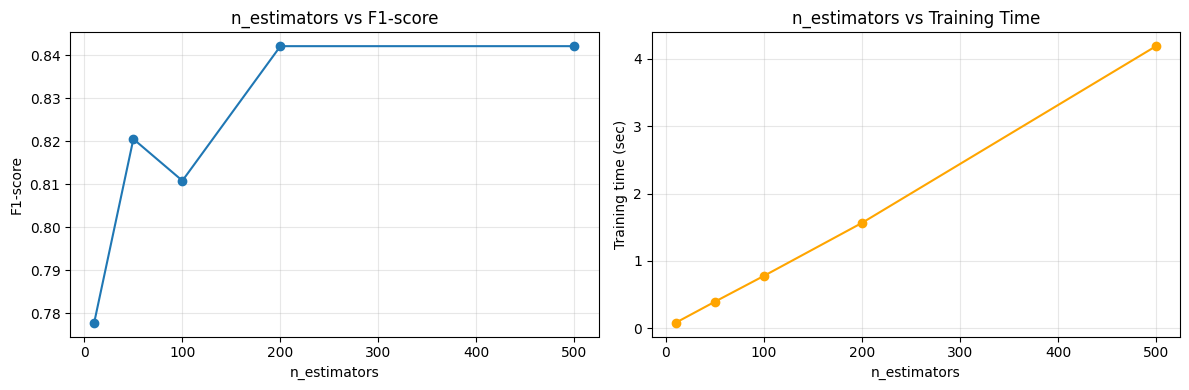

In [22]:
import time

n_estimators_list = [10, 50, 100, 200, 500]
f1_scores = []
train_times = []

for n in n_estimators_list:
    start = time.perf_counter()
    rf_n = RandomForestClassifier(n_estimators=n, random_state=0)
    rf_n.fit(X_train_cls, Y_train_cls)
    elapsed = time.perf_counter() - start

    pred = rf_n.predict(X_test_cls)
    f1_scores.append(f1_score(Y_test_cls, pred))
    train_times.append(elapsed)

result_df = pd.DataFrame({
    "n_estimators": n_estimators_list,
    "F1-score": f1_scores,
    "train_time_sec": train_times,
})
print(result_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(n_estimators_list, f1_scores, marker="o")
axes[0].set_xlabel("n_estimators")
axes[0].set_ylabel("F1-score")
axes[0].set_title("n_estimators vs F1-score")
axes[0].grid(True, alpha=0.3)

axes[1].plot(n_estimators_list, train_times, marker="o", color="orange")
axes[1].set_xlabel("n_estimators")
axes[1].set_ylabel("Training time (sec)")
axes[1].set_title("n_estimators vs Training Time")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 해석: 학습 시간은 n_estimators에 대략 비례(선형)하게 증가한다.
# F1은 어느 정도 커지면 수렴하므로, 성능 대비 시간을 고려해 적절한 값을 선택해야 한다.